# Lab 19d - Where did the full-list ranking go?

Lab 19 produced a clean failure. Both continuation arms learned their
twelve-action objective, but answer-constrained solve rate fell from 10/19 for
every incumbent to 4/19, 4/19, and 1/19 for the hard arms and 0/19 for every
value arm.

This notebook does not train or score a model. Lab 18d and Lab 19 already
persisted every 2,315-answer score vector needed for two targeted analyses:

1. Turn 2 is paired across incumbents and trained arms because every game starts
   from the fixed `RAISE` opener.
2. Singleton states reveal whether the known answer remained competitive on
   each model's own deployed trajectory.

The question is whether Lab 19 merely suppressed the incumbent's original
top-ranked mistakes and allowed previously lower-ranked words to become the new
winners, or whether continued training caused a broader loss of useful ranking.

## 19d.1 Pre-registered questions

**Primary question.** On paired Turn 2 states, where did each trained winner
rank under its frozen incumbent?

The leading negative-churn hypothesis predicts:

```text
incumbent mistakes are included in the twelve-action support
-> training moves those comparisons
-> previously lower-ranked unsupported words become the new winners
```

Evidence for that account would include trained winners coming from below the
incumbent top 32, low exposure of those words in the training supports, and
worse candidate or teacher ranks despite improved twelve-action dev metrics.

**Competing explanation.** The trained winner may already have been highly
ranked or repeatedly exposed. In that case, stale hard negatives are not enough
to explain the failure. Score loss on candidates and teacher actions would
instead point toward broader policy drift or missing preservation pressure.

**Singleton question.** On states with exactly one candidate, what rank and
score margin does the sole candidate receive? Singleton trajectories are not
paired after Turn 2, so this is a deployed-behavior diagnosis rather than a
controlled state comparison.

**No new model calls.** Every score matrix comes from the exact scorer used in
Labs 18d and 19. This notebook fails if manifests, answer order, scorer hashes,
row keys, or score shapes disagree.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from tiny_wordle.expert import EntropyExpert
from tiny_wordle.game import Turn, score_string

SEEDS = [42, 45, 47]
TRAINED_ARMS = ["hard", "value"]
OPENING = "RAISE"
TOP_K = 32

DATA_DIR = Path("../data")
GENERATED_DIR = DATA_DIR / "generated"
LAB18D_DIR = Path("../results/lab18d")
LAB19_DIR = Path("../results/lab19")
RESULTS_DIR = Path("../results/lab19d")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

ANSWERS = [
    line.strip().upper()
    for line in (DATA_DIR / "wordle-answers-original.txt").read_text().splitlines()
    if line.strip()
]
ANSWER_ARRAY = np.array(ANSWERS)
WORD_TO_INDEX = {word: index for index, word in enumerate(ANSWERS)}
ANSWER_SET = set(ANSWERS)
PATTERNS = np.load(DATA_DIR / "wordle-patterns-original-2315.npy")
expert = EntropyExpert(ANSWERS, PATTERNS)
ALL_INDICES = expert.all_indices

assert len(ANSWERS) == 2315
assert len(ANSWER_SET) == len(ANSWERS)
assert PATTERNS.shape == (2315, 2315)
assert expert.word_to_index == WORD_TO_INDEX

## 19d.2 Freeze provenance and answer order

The incumbent score vectors come from Lab 18d. The trained score vectors,
training supports, and adapter identities come from Lab 19. A shared scorer
hash is necessary because rank movement is meaningful only when both labs
scored the same strings in the same order with the same EOS convention.

In [2]:
lab18d_run = json.loads((LAB18D_DIR / "lab18d-run.json").read_text())
lab19_run = json.loads((LAB19_DIR / "lab19-run.json").read_text())
target_manifest = json.loads(
    (GENERATED_DIR / "lab19-value-targets-manifest.json").read_text()
)

assert lab18d_run["seeds"] == SEEDS
assert lab19_run["seeds"] == SEEDS
assert lab19_run["arms"] == TRAINED_ARMS
assert lab18d_run["answers"] == lab19_run["reserved_answers"]
assert lab18d_run["opening"] == lab19_run["opening"] == OPENING
assert lab18d_run["action_space"] == lab19_run["action_space"]
assert lab18d_run["checkpoint_sha256"] == lab19_run["incumbent_sha256"]
assert lab19_run["scorer_sha256"] == target_manifest["scorer_sha256"]
assert target_manifest["config"]["mining_top_k"] == TOP_K
assert target_manifest["config"]["action_space"] == "2,315 answer words"

RESERVED_ANSWERS = lab18d_run["answers"]
print("reserved answers:", len(RESERVED_ANSWERS))
print("shared scorer:", lab19_run["scorer_sha256"][:16])
print("action order:", len(ANSWERS), ANSWERS[:3], "...", ANSWERS[-3:])

reserved answers: 19
shared scorer: 2e35dbf6edcad821
action order: 2315 ['ABACK', 'ABASE', 'ABATE'] ... ['ZEBRA', 'ZESTY', 'ZONAL']


In [3]:
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def rank_vector(scores: np.ndarray) -> np.ndarray:
    order = np.argsort(-scores, kind="stable")
    ranks = np.empty(len(scores), dtype=np.int32)
    ranks[order] = np.arange(1, len(scores) + 1)
    return ranks


def probability_mass(scores: np.ndarray, indices: np.ndarray) -> float:
    shifted = scores - scores.max()
    weights = np.exp(shifted)
    return float(weights[indices].sum() / weights.sum())


def indices_from_history(history: list[Turn]) -> np.ndarray:
    indices = ALL_INDICES
    for turn in history:
        indices = expert.update(
            indices, WORD_TO_INDEX[turn.guess], turn.feedback
        )
    if len(indices) == 0:
        raise AssertionError("history removed the hidden answer")
    return indices


def candidate_indices(answer: str, history: list[Turn] | None = None) -> np.ndarray:
    turns = history or [Turn(OPENING, score_string(answer, OPENING))]
    indices = indices_from_history(turns)
    assert WORD_TO_INDEX[answer] in set(indices)
    return indices


def parse_state_key(state_key: str) -> list[Turn]:
    history = []
    for line in state_key.splitlines():
        guess_text, feedback_text = line.split(" -> ")
        history.append(Turn(
            guess=guess_text.replace(" ", ""),
            feedback=feedback_text.replace(" ", ""),
        ))
    return history


def atomic_csv(frame: pd.DataFrame, path: Path) -> None:
    temporary = path.with_suffix(path.suffix + ".tmp")
    frame.to_csv(temporary, index=False)
    temporary.replace(path)


def atomic_json(value: dict, path: Path) -> None:
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(json.dumps(value, indent=2))
    temporary.replace(path)

## 19d.3 Load the persisted full-list scores

Lab 18d stored one incumbent matrix per seed. Lab 19 stored one matrix per
seed and continuation arm. The score-key CSV is the row index for each matrix.
Only Turn 2 rows enter the paired analysis.

In [4]:
def score_paths(seed: int, arm: str) -> tuple[Path, Path, Path]:
    if arm == "incumbent":
        stem = LAB18D_DIR / f"seed{seed}-answer-constrained"
    else:
        stem = LAB19_DIR / f"seed{seed}-{arm}-answer-constrained"
    return (
        stem.with_name(stem.name + "-score-keys.csv"),
        stem.with_name(stem.name + "-scores.npy"),
        stem.with_name(stem.name + "-calls.csv"),
    )


score_bundles = {}
input_paths = [
    DATA_DIR / "wordle-answers-original.txt",
    DATA_DIR / "wordle-patterns-original-2315.npy",
    LAB18D_DIR / "lab18d-run.json",
    LAB19_DIR / "lab19-run.json",
    GENERATED_DIR / "lab19-value-targets-manifest.json",
]

for seed in SEEDS:
    for arm in ["incumbent"] + TRAINED_ARMS:
        keys_path, scores_path, calls_path = score_paths(seed, arm)
        keys = pd.read_csv(keys_path)
        scores = np.load(scores_path)
        calls = pd.read_csv(calls_path)
        assert scores.shape == (len(keys), len(ANSWERS))
        assert np.isfinite(scores).all()
        assert not keys.duplicated(["seed", "answer", "turn"]).any()
        assert set(keys["answer"]) == set(RESERVED_ANSWERS)
        assert set(keys["seed"]) == {seed}
        if "arm" in keys:
            assert set(keys["arm"]) == {arm}
        turn2 = keys.index[keys["turn"] == 2].to_numpy()
        assert len(turn2) == len(RESERVED_ANSWERS)
        assert set(keys.loc[turn2, "answer"]) == set(RESERVED_ANSWERS)
        score_bundles[(seed, arm)] = {
            "keys": keys,
            "scores": scores,
            "calls": calls,
            "turn2_rows": {
                keys.loc[position, "answer"]: int(position)
                for position in turn2
            },
        }
        input_paths.extend([keys_path, scores_path, calls_path])

print("loaded score bundles:", len(score_bundles))
print("paired Turn 2 states:", len(SEEDS) * len(RESERVED_ANSWERS))

loaded score bundles: 9
paired Turn 2 states: 57


## 19d.4 Audit argmax and row alignment

The recorded constrained guess must be the argmax of its persisted score
vector. Turn 2 teacher fields must also agree across the incumbent and both
trained arms because all three see the same state after `RAISE`.

In [5]:
for (seed, arm), bundle in score_bundles.items():
    calls = bundle["calls"].query("decoder == 'answer-constrained'")
    call_lookup = calls.set_index(["answer", "turn"])
    for position, key in bundle["keys"].iterrows():
        scores = bundle["scores"][position]
        expected = ANSWERS[int(scores.argmax())]
        observed = call_lookup.loc[(key["answer"], key["turn"]), "guess"]
        assert expected == observed

for seed in SEEDS:
    incumbent_calls = (
        score_bundles[(seed, "incumbent")]["calls"]
        .query("decoder == 'answer-constrained' and turn == 2")
        .set_index("answer")
    )
    for arm in TRAINED_ARMS:
        trained_calls = (
            score_bundles[(seed, arm)]["calls"]
            .query("decoder == 'answer-constrained' and turn == 2")
            .set_index("answer")
        )
        for column in [
            "candidate_count_before",
            "teacher_guess",
            "open_teacher_guess",
            "teacher_entropy_bits",
            "open_teacher_entropy_bits",
        ]:
            pd.testing.assert_series_equal(
                incumbent_calls[column].sort_index(),
                trained_calls[column].sort_index(),
                check_names=False,
            )

print("argmax, row-key, and paired-state audits passed")

argmax, row-key, and paired-state audits passed


## 19d.5 Measure training-support exposure

The held-out gameplay states were excluded from training, so no exact support
should match them. This section asks a narrower word-level question: did a new
deployed winner appear anywhere in that seed's training supports, and was it
ever selected as one of the incumbent hard negatives?

Global exposure cannot prove that the model received the right comparison at
the right state. It can distinguish a completely unseen competitor from a word
that appeared repeatedly under other histories.

In [6]:
def read_jsonl(path: Path) -> list[dict]:
    return [
        json.loads(line)
        for line in path.read_text().splitlines()
        if line.strip()
    ]


exposure_rows = []
for seed in SEEDS:
    path = GENERATED_DIR / f"lab19-value-targets-seed{seed}-train.jsonl"
    records = read_jsonl(path)
    assert len(records) == target_manifest["counts"]["train_states"]
    input_paths.append(path)
    for record in records:
        candidate_positions = set(record["candidate_positions"])
        incumbent_positions = set(record["incumbent_positions"])
        for position, word in enumerate(record["actions"]):
            exposure_rows.append({
                "seed": seed,
                "state_key": record["state_key"],
                "regime": record["regime"],
                "word": word,
                "in_support": 1,
                "incumbent_negative": int(position in incumbent_positions),
                "candidate_slot": int(position in candidate_positions),
                "hard_target": int(position == record["hard_index"]),
                "value_target": record["value_target"][position],
            })

support_exposure = pd.DataFrame(exposure_rows)
support_exposure_summary = support_exposure.groupby(
    ["seed", "word"], sort=True
).agg(
    support_count=("in_support", "sum"),
    incumbent_negative_count=("incumbent_negative", "sum"),
    candidate_slot_count=("candidate_slot", "sum"),
    hard_target_count=("hard_target", "sum"),
    total_value_target=("value_target", "sum"),
).reset_index()
support_exposure_by_regime = support_exposure.groupby(
    ["seed", "regime", "word"], sort=True
).agg(
    support_count=("in_support", "sum"),
    incumbent_negative_count=("incumbent_negative", "sum"),
    candidate_slot_count=("candidate_slot", "sum"),
    hard_target_count=("hard_target", "sum"),
    total_value_target=("value_target", "sum"),
).reset_index()

assert len(support_exposure) == (
    len(SEEDS)
    * target_manifest["counts"]["train_states"]
    * target_manifest["config"]["support_size"]
)
reserved_indices = {WORD_TO_INDEX[word] for word in RESERVED_ANSWERS}
for seed in SEEDS:
    records = read_jsonl(
        GENERATED_DIR / f"lab19-value-targets-seed{seed}-train.jsonl"
    )
    for record in records:
        history = parse_state_key(record["state_key"])
        if history and history[0].guess == OPENING:
            reachable = set(indices_from_history(history))
            assert reserved_indices.isdisjoint(reachable), (
                f"reserved-answer-reachable training state: seed {seed} "
                f"{record['state_key']!r}"
            )

display(
    support_exposure_summary.groupby("seed").agg(
        exposed_words=("word", "nunique"),
        support_presentations=("support_count", "sum"),
        incumbent_negative_presentations=("incumbent_negative_count", "sum"),
    )
)

,exposed_words,support_presentations,incumbent_negative_presentations
seed,,,
42,2184,12348,4116
45,2187,12348,4116
47,2189,12348,4116


## 19d.6 Paired Turn 2 rank drift

For each seed-answer pair, compare one incumbent score vector with each trained
arm on the same state. Ranks are one-based over all 2,315 answers.

The score decomposition keeps two words fixed:

* the incumbent winner;
* the trained winner.

If the trained winner mainly rises while the incumbent winner stays stable,
new competitors took over. If the incumbent winner, candidates, and teacher
actions all lose score, the update caused broader forgetting. Both can happen
together.

In [7]:
exposure_lookup = support_exposure_summary.set_index(["seed", "word"])
turn2_rows = []
shift_rows = []

for seed in SEEDS:
    incumbent = score_bundles[(seed, "incumbent")]
    incumbent_calls = (
        incumbent["calls"]
        .query("decoder == 'answer-constrained' and turn == 2")
        .set_index("answer")
    )
    for answer in RESERVED_ANSWERS:
        inc_position = incumbent["turn2_rows"][answer]
        inc_scores = incumbent["scores"][inc_position]
        inc_ranks = rank_vector(inc_scores)
        inc_winner_index = int(inc_scores.argmax())
        candidates = candidate_indices(answer)
        assert len(candidates) == int(
            incumbent_calls.loc[answer, "candidate_count_before"]
        )
        teacher_word = incumbent_calls.loc[answer, "teacher_guess"]
        open_teacher_word = incumbent_calls.loc[answer, "open_teacher_guess"]
        teacher_index = WORD_TO_INDEX[teacher_word]
        open_teacher_index = WORD_TO_INDEX[open_teacher_word]

        for arm in TRAINED_ARMS:
            trained = score_bundles[(seed, arm)]
            trained_position = trained["turn2_rows"][answer]
            trained_scores = trained["scores"][trained_position]
            trained_ranks = rank_vector(trained_scores)
            trained_winner_index = int(trained_scores.argmax())
            trained_winner = ANSWERS[trained_winner_index]
            incumbent_winner = ANSWERS[inc_winner_index]
            exposure_key = (seed, trained_winner)
            exposure = (
                exposure_lookup.loc[exposure_key]
                if exposure_key in exposure_lookup.index
                else None
            )

            trained_winner_delta = float(
                trained_scores[trained_winner_index]
                - inc_scores[trained_winner_index]
            )
            incumbent_winner_delta = float(
                trained_scores[inc_winner_index]
                - inc_scores[inc_winner_index]
            )
            incumbent_margin = float(
                inc_scores[trained_winner_index]
                - inc_scores[inc_winner_index]
            )
            trained_margin = float(
                trained_scores[trained_winner_index]
                - trained_scores[inc_winner_index]
            )

            row = {
                "seed": seed,
                "answer": answer,
                "arm": arm,
                "candidate_count": len(candidates),
                "incumbent_winner": incumbent_winner,
                "trained_winner": trained_winner,
                "winner_changed": trained_winner_index != inc_winner_index,
                "trained_winner_incumbent_rank": int(
                    inc_ranks[trained_winner_index]
                ),
                "trained_winner_below_incumbent_top32": bool(
                    inc_ranks[trained_winner_index] > TOP_K
                ),
                "incumbent_winner_trained_rank": int(
                    trained_ranks[inc_winner_index]
                ),
                "trained_winner_score_delta": trained_winner_delta,
                "incumbent_winner_score_delta": incumbent_winner_delta,
                "winner_relative_margin_change": (
                    trained_margin - incumbent_margin
                ),
                "incumbent_best_candidate_rank": int(
                    inc_ranks[candidates].min()
                ),
                "trained_best_candidate_rank": int(
                    trained_ranks[candidates].min()
                ),
                "best_candidate_rank_change": int(
                    trained_ranks[candidates].min()
                    - inc_ranks[candidates].min()
                ),
                "incumbent_candidate_mass": probability_mass(
                    inc_scores, candidates
                ),
                "trained_candidate_mass": probability_mass(
                    trained_scores, candidates
                ),
                "candidate_mass_change": (
                    probability_mass(trained_scores, candidates)
                    - probability_mass(inc_scores, candidates)
                ),
                "candidate_teacher": teacher_word,
                "incumbent_candidate_teacher_rank": int(
                    inc_ranks[teacher_index]
                ),
                "trained_candidate_teacher_rank": int(
                    trained_ranks[teacher_index]
                ),
                "candidate_teacher_rank_change": int(
                    trained_ranks[teacher_index] - inc_ranks[teacher_index]
                ),
                "candidate_teacher_score_delta": float(
                    trained_scores[teacher_index] - inc_scores[teacher_index]
                ),
                "open_teacher": open_teacher_word,
                "incumbent_open_teacher_rank": int(
                    inc_ranks[open_teacher_index]
                ),
                "trained_open_teacher_rank": int(
                    trained_ranks[open_teacher_index]
                ),
                "open_teacher_rank_change": int(
                    trained_ranks[open_teacher_index]
                    - inc_ranks[open_teacher_index]
                ),
                "open_teacher_score_delta": float(
                    trained_scores[open_teacher_index]
                    - inc_scores[open_teacher_index]
                ),
                "winner_any_support_count": (
                    int(exposure["support_count"]) if exposure is not None else 0
                ),
                "winner_incumbent_negative_count": (
                    int(exposure["incumbent_negative_count"])
                    if exposure is not None else 0
                ),
                "winner_hard_target_count": (
                    int(exposure["hard_target_count"])
                    if exposure is not None else 0
                ),
            }
            turn2_rows.append(row)

            outside_top32 = np.flatnonzero(inc_ranks > TOP_K)
            shift_rows.append({
                "seed": seed,
                "answer": answer,
                "arm": arm,
                "trained_winner_delta": trained_winner_delta,
                "incumbent_winner_delta": incumbent_winner_delta,
                "candidate_mean_delta": float(
                    np.mean(trained_scores[candidates] - inc_scores[candidates])
                ),
                "incumbent_top32_mean_delta": float(np.mean(
                    trained_scores[inc_ranks <= TOP_K]
                    - inc_scores[inc_ranks <= TOP_K]
                )),
                "outside_top32_mean_delta": float(np.mean(
                    trained_scores[outside_top32] - inc_scores[outside_top32]
                )),
                "candidate_teacher_delta": float(
                    trained_scores[teacher_index] - inc_scores[teacher_index]
                ),
                "open_teacher_delta": float(
                    trained_scores[open_teacher_index]
                    - inc_scores[open_teacher_index]
                ),
            })

turn2_drift = pd.DataFrame(turn2_rows)
score_shift = pd.DataFrame(shift_rows)
assert len(turn2_drift) == len(SEEDS) * len(RESERVED_ANSWERS) * len(TRAINED_ARMS)
assert turn2_drift.groupby(["seed", "arm"]).size().eq(19).all()
display(turn2_drift.head())

,seed,answer,arm,candidate_count,incumbent_winner,trained_winner,winner_changed,trained_winner_incumbent_rank,trained_winner_below_incumbent_top32,incumbent_winner_trained_rank,...,candidate_teacher_rank_change,candidate_teacher_score_delta,open_teacher,incumbent_open_teacher_rank,trained_open_teacher_rank,open_teacher_rank_change,open_teacher_score_delta,winner_any_support_count,winner_incumbent_negative_count,winner_hard_target_count
0,42,SHORE,hard,10,SHORE,ROYAL,True,600,True,325,...,290,-7.880675,PERCH,1580,1272,-308,10.591770,5,0,1
1,42,SHORE,value,10,SHORE,FALSE,True,333,True,1278,...,1312,-11.556211,PERCH,1580,985,-595,8.767489,1,0,0
2,42,MIGHT,hard,107,BLOWN,JOLLY,True,415,True,359,...,344,-1.937035,PILOT,325,669,344,-1.937035,1,1,0
3,42,MIGHT,value,107,BLOWN,JOLLY,True,415,True,743,...,1297,-5.650445,PILOT,325,1622,1297,-5.650445,1,1,0
4,42,BRICK,hard,28,DRIER,MOTIF,True,356,True,1687,...,134,-1.715571,CRYPT,76,268,192,-3.735378,2,0,1


In [8]:
turn2_summary = turn2_drift.groupby(["seed", "arm"], sort=True).agg(
    states=("answer", "size"),
    winner_change_rate=("winner_changed", "mean"),
    winner_below_top32_rate=(
        "trained_winner_below_incumbent_top32", "mean"
    ),
    median_trained_winner_incumbent_rank=(
        "trained_winner_incumbent_rank", "median"
    ),
    mean_trained_winner_incumbent_rank=(
        "trained_winner_incumbent_rank", "mean"
    ),
    median_incumbent_winner_trained_rank=(
        "incumbent_winner_trained_rank", "median"
    ),
    mean_winner_score_delta=("trained_winner_score_delta", "mean"),
    mean_incumbent_winner_score_delta=(
        "incumbent_winner_score_delta", "mean"
    ),
    mean_best_candidate_rank_change=("best_candidate_rank_change", "mean"),
    mean_candidate_mass_change=("candidate_mass_change", "mean"),
    mean_candidate_teacher_rank_change=(
        "candidate_teacher_rank_change", "mean"
    ),
    mean_open_teacher_rank_change=("open_teacher_rank_change", "mean"),
    winner_never_in_support_rate=(
        "winner_any_support_count", lambda values: float((values == 0).mean())
    ),
    winner_never_mined_negative_rate=(
        "winner_incumbent_negative_count",
        lambda values: float((values == 0).mean()),
    ),
).reset_index()

display(turn2_summary.round(4))

,seed,arm,states,winner_change_rate,winner_below_top32_rate,median_trained_winner_incumbent_rank,mean_trained_winner_incumbent_rank,median_incumbent_winner_trained_rank,mean_winner_score_delta,mean_incumbent_winner_score_delta,mean_best_candidate_rank_change,mean_candidate_mass_change,mean_candidate_teacher_rank_change,mean_open_teacher_rank_change,winner_never_in_support_rate,winner_never_mined_negative_rate
0,42,hard,19,1.0,1.0000,528.0,542.6842,333.0,5.5854,-10.5268,35.7368,-0.2090,88.2632,-42.0000,0.0,0.2105
1,42,value,19,1.0,0.9474,185.0,245.2105,743.0,-2.0271,-13.5913,117.9474,-0.2480,337.6316,241.1053,0.0,0.7895
2,45,hard,19,1.0,1.0000,351.0,499.3684,464.0,4.9319,-10.4908,30.8421,-0.2112,193.9474,163.2105,0.0,0.0526
3,45,value,19,1.0,0.9474,208.0,268.7368,468.0,-0.6533,-12.5643,109.2105,-0.2438,360.8947,296.6842,0.0,0.0000
4,47,hard,19,1.0,0.9474,657.0,584.8421,614.0,5.9885,-11.1083,37.2105,-0.1976,194.7368,114.8947,0.0,0.6316
5,47,value,19,1.0,0.8947,130.0,380.3158,840.0,-0.1463,-13.0309,152.7368,-0.2326,396.4211,351.7368,0.0,0.7368


In [9]:
shift_summary = score_shift.groupby(["seed", "arm"], sort=True).agg(
    trained_winner_delta=("trained_winner_delta", "mean"),
    incumbent_winner_delta=("incumbent_winner_delta", "mean"),
    candidate_mean_delta=("candidate_mean_delta", "mean"),
    incumbent_top32_mean_delta=("incumbent_top32_mean_delta", "mean"),
    outside_top32_mean_delta=("outside_top32_mean_delta", "mean"),
    candidate_teacher_delta=("candidate_teacher_delta", "mean"),
    open_teacher_delta=("open_teacher_delta", "mean"),
).reset_index()
display(shift_summary.round(4))

,seed,arm,trained_winner_delta,incumbent_winner_delta,candidate_mean_delta,incumbent_top32_mean_delta,outside_top32_mean_delta,candidate_teacher_delta,open_teacher_delta
0,42,hard,5.5854,-10.5268,-3.4655,-7.1942,6.0370,-1.3808,2.6783
1,42,value,-2.0271,-13.5913,-6.3654,-10.0217,4.1286,-4.6001,-0.0921
2,45,hard,4.9319,-10.4908,-3.0210,-7.0270,6.6343,-1.6546,2.4681
3,45,value,-0.6533,-12.5643,-5.1626,-9.0827,5.3576,-3.9115,0.7292
4,47,hard,5.9885,-11.1083,-3.2476,-7.1920,6.6954,-1.4495,3.0984
5,47,value,-0.1463,-13.0309,-5.3875,-9.2278,5.6273,-3.7223,1.3543


## 19d.7 Visualize winner origin and candidate drift

The first plot shows the incumbent rank of each trained Turn 2 winner. The
dashed line is the top-32 mining boundary. The second shows how the trained
policy changed the best current candidate's rank. Positive values are worse.

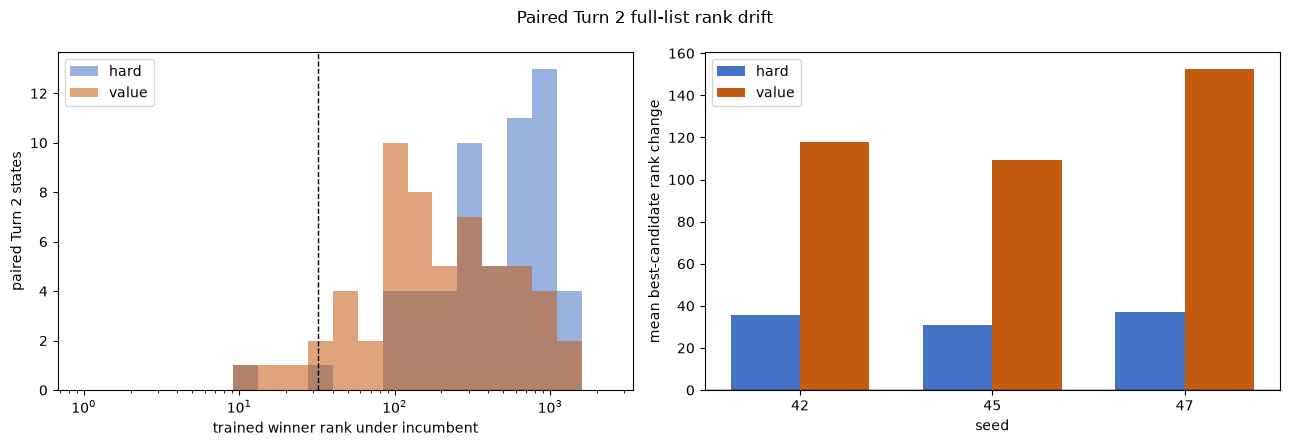

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors = {"hard": "#4472C4", "value": "#C55A11"}

for arm in TRAINED_ARMS:
    values = turn2_drift.loc[
        turn2_drift["arm"] == arm, "trained_winner_incumbent_rank"
    ]
    axes[0].hist(
        values,
        bins=np.geomspace(1, len(ANSWERS) + 1, 22),
        alpha=0.55,
        label=arm,
        color=colors[arm],
    )
axes[0].axvline(TOP_K, color="black", linestyle="--", linewidth=1)
axes[0].set_xscale("log")
axes[0].set_xlabel("trained winner rank under incumbent")
axes[0].set_ylabel("paired Turn 2 states")
axes[0].legend()

positions = np.arange(len(SEEDS))
width = 0.36
for offset, arm in enumerate(TRAINED_ARMS):
    values = (
        turn2_summary.query("arm == @arm")
        .set_index("seed")
        .loc[SEEDS, "mean_best_candidate_rank_change"]
    )
    axes[1].bar(
        positions + (offset - 0.5) * width,
        values,
        width=width,
        label=arm,
        color=colors[arm],
    )
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xticks(positions, SEEDS)
axes[1].set_xlabel("seed")
axes[1].set_ylabel("mean best-candidate rank change")
axes[1].legend()

fig.suptitle("Paired Turn 2 full-list rank drift")
fig.tight_layout()
plt.show()

## 19d.8 Inspect the largest winner turnovers

These rows are descriptive examples selected by the preregistered quantity:
the trained winner's rank under the incumbent. They are not hand-picked by
whether their words make a persuasive story.

In [11]:
largest_turnovers = (
    turn2_drift.sort_values(
        ["trained_winner_incumbent_rank", "winner_relative_margin_change"],
        ascending=[False, False],
    )
    .groupby(["seed", "arm"], sort=True)
    .head(5)
)
display(largest_turnovers[[
    "seed",
    "arm",
    "answer",
    "candidate_count",
    "incumbent_winner",
    "trained_winner",
    "trained_winner_incumbent_rank",
    "incumbent_winner_trained_rank",
    "trained_winner_score_delta",
    "incumbent_winner_score_delta",
    "winner_any_support_count",
    "winner_incumbent_negative_count",
    "best_candidate_rank_change",
]].round(4))

,seed,arm,answer,candidate_count,incumbent_winner,trained_winner,trained_winner_incumbent_rank,incumbent_winner_trained_rank,trained_winner_score_delta,incumbent_winner_score_delta,winner_any_support_count,winner_incumbent_negative_count,best_candidate_rank_change
72,45,hard,ALLEY,69,ALIGN,ROYAL,1284,769,9.9348,-11.1035,6,1,9
100,47,hard,SLATE,20,SAUCE,ROYAL,1173,1338,13.2611,-12.5767,5,0,3
101,47,value,SLATE,20,SAUCE,ROYAL,1173,1331,9.4656,-13.5188,5,0,15
62,45,hard,SLATE,20,STALE,ROYAL,1171,715,12.6663,-11.2530,6,1,1
110,47,hard,ALLEY,69,BETEL,ROYAL,1120,614,9.2223,-11.2050,5,0,9
111,47,value,ALLEY,69,BETEL,ROYAL,1120,475,5.2558,-12.6239,5,0,36
66,45,hard,APPLE,41,CABLE,ROYAL,1092,188,9.3328,-9.6370,6,1,-3
104,47,hard,APPLE,41,LANCE,ROYAL,1055,1065,11.1580,-12.2256,5,0,-4
106,47,hard,SHEEP,41,STONE,ROYAL,1012,510,10.9483,-11.8519,5,0,-1
107,47,value,SHEEP,41,STONE,ROYAL,1012,1003,7.3298,-14.1020,5,0,9


## 19d.9 Diagnose singleton ranking on deployed trajectories

For each answer-constrained trajectory, reconstruct the candidate set before
every action. When exactly one candidate remains, record its full-list rank,
probability mass, and score margin behind the chosen action.

Only the first singleton state per game estimates closure. Later singleton
calls often repeat the same failure and must not inflate the denominator.

In [12]:
def singleton_rows_for_bundle(seed: int, arm: str) -> list[dict]:
    bundle = score_bundles[(seed, arm)]
    key_to_position = {
        (row.answer, int(row.turn)): int(position)
        for position, row in bundle["keys"].iterrows()
    }
    calls = (
        bundle["calls"]
        .query("decoder == 'answer-constrained'")
        .sort_values(["answer", "turn"])
    )
    rows = []
    for answer, game_calls in calls.groupby("answer", sort=False):
        history = [Turn(OPENING, score_string(answer, OPENING))]
        first_singleton_seen = False
        for call in game_calls.itertuples():
            candidates = candidate_indices(answer, history)
            assert len(candidates) == int(call.candidate_count_before)
            position = key_to_position[(answer, int(call.turn))]
            scores = bundle["scores"][position]
            ranks = rank_vector(scores)
            chosen_index = int(scores.argmax())
            assert ANSWERS[chosen_index] == call.guess
            if len(candidates) == 1:
                sole_index = int(candidates[0])
                rows.append({
                    "seed": seed,
                    "arm": arm,
                    "answer": answer,
                    "turn": int(call.turn),
                    "first_singleton": not first_singleton_seen,
                    "sole_candidate": ANSWERS[sole_index],
                    "chosen": call.guess,
                    "closed": chosen_index == sole_index,
                    "sole_candidate_rank": int(ranks[sole_index]),
                    "chosen_rank": int(ranks[chosen_index]),
                    "score_margin_behind_winner": float(
                        scores[chosen_index] - scores[sole_index]
                    ),
                    "sole_candidate_mass": probability_mass(
                        scores, np.array([sole_index])
                    ),
                    "repeated": bool(call.repeated),
                })
                first_singleton_seen = True
            history.append(Turn(call.guess, call.feedback))
    return rows


singleton_rows = []
for seed in SEEDS:
    for arm in ["incumbent"] + TRAINED_ARMS:
        singleton_rows.extend(singleton_rows_for_bundle(seed, arm))

singleton_drift = pd.DataFrame(singleton_rows)
assert len(singleton_drift) > 0
assert singleton_drift["sole_candidate_rank"].ge(1).all()
assert singleton_drift["sole_candidate_rank"].le(len(ANSWERS)).all()

first_singleton = singleton_drift.query("first_singleton").copy()
singleton_summary = first_singleton.groupby(["seed", "arm"], sort=True).agg(
    games_reaching_singleton=("answer", "size"),
    close_rate=("closed", "mean"),
    median_sole_candidate_rank=("sole_candidate_rank", "median"),
    mean_sole_candidate_rank=("sole_candidate_rank", "mean"),
    mean_margin_behind_winner=("score_margin_behind_winner", "mean"),
    mean_sole_candidate_mass=("sole_candidate_mass", "mean"),
).reset_index()
display(singleton_summary.round(4))

,seed,arm,games_reaching_singleton,close_rate,median_sole_candidate_rank,mean_sole_candidate_rank,mean_margin_behind_winner,mean_sole_candidate_mass
0,42,hard,16,0.1875,41.0,100.4375,1.9214,0.0332
1,42,incumbent,13,0.3846,2.0,5.0000,1.0953,0.3035
2,42,value,13,0.0000,593.0,694.3077,2.2942,0.0012
3,45,hard,15,0.0667,120.0,264.7333,2.0942,0.0035
4,45,incumbent,11,0.4545,3.0,5.0000,1.6081,0.3631
5,45,value,15,0.0000,381.0,729.3333,2.6147,0.0009
6,47,hard,16,0.0625,168.5,372.5625,2.8093,0.0172
7,47,incumbent,12,0.5000,1.5,7.2500,1.2053,0.2776
8,47,value,11,0.0000,996.0,954.7273,2.6870,0.0005


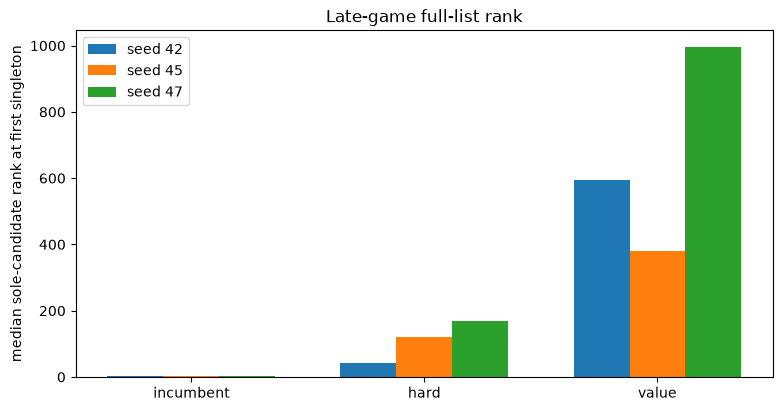

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
labels = ["incumbent", "hard", "value"]
positions = np.arange(len(labels))
width = 0.24
for offset, seed in enumerate(SEEDS):
    values = (
        singleton_summary.query("seed == @seed")
        .set_index("arm")
        .loc[labels, "median_sole_candidate_rank"]
    )
    ax.bar(
        positions + (offset - 1) * width,
        values,
        width=width,
        label=f"seed {seed}",
    )
ax.set_xticks(positions, labels)
ax.set_ylabel("median sole-candidate rank at first singleton")
ax.set_title("Late-game full-list rank")
ax.legend()
plt.show()

## 19d.10 Cross-check against the published Lab 19 summaries

Reconstructed first-singleton closure and Turn 2 candidate mass must reproduce
the persisted Lab 19 tables. This catches a history reconstruction or score-row
alignment bug before interpretation.

In [14]:
published_closure = pd.read_csv(LAB19_DIR / "closure-summary.csv")
published_turn2 = pd.read_csv(LAB19_DIR / "turn2-summary.csv")
input_paths.extend([
    LAB19_DIR / "closure-summary.csv",
    LAB19_DIR / "turn2-summary.csv",
])

for row in singleton_summary.itertuples():
    published = published_closure.query(
        "seed == @row.seed and arm == @row.arm "
        "and decoder == 'answer-constrained'"
    )
    assert len(published) == 1
    assert math.isclose(
        row.close_rate,
        float(published.iloc[0]["first_singleton_close_rate"]),
        abs_tol=1e-12,
    )

for row in turn2_summary.itertuples():
    published_arm = published_turn2.query(
        "seed == @row.seed and arm == @row.arm "
        "and decoder == 'answer-constrained'"
    )
    incumbent_arm = published_turn2.query(
        "seed == @row.seed and arm == 'incumbent' "
        "and decoder == 'answer-constrained'"
    )
    assert len(published_arm) == len(incumbent_arm) == 1
    observed_change = (
        float(published_arm.iloc[0]["mean_candidate_mass"])
        - float(incumbent_arm.iloc[0]["mean_candidate_mass"])
    )
    assert math.isclose(
        row.mean_candidate_mass_change,
        observed_change,
        abs_tol=1e-7,
    )

print("published-summary cross-checks passed")

published-summary cross-checks passed


## 19d.11 Interpretation order

Read the results in this order:

1. **Winner origin.** Did trained winners come from below the incumbent top 32?
2. **Exposure.** Were those words absent from all training supports, or merely
   absent from the correct state-level comparison?
3. **Score decomposition.** Did new winners rise, did incumbent winners and
   candidates fall, or did both happen?
4. **Teacher and candidate ranks.** Did the full-list ordering move away from
   strategically useful actions on all three seeds?
5. **Singleton rank.** Did the sole candidate become a distant full-list action
   even though its target was one-hot inside the twelve-action support?

The possible conclusions are deliberately narrower than "distillation works"
or "distillation fails."

| observed pattern | supported interpretation |
| --- | --- |
| new winners mostly came from below top 32 and lacked support exposure | frozen negative mining missed the competitors that later took over |
| new winners were exposed repeatedly but won anyway | global exposure without the correct state-level comparison was insufficient |
| candidates and teacher actions lost score broadly | continuation lacked enough preservation pressure |
| new winners rose while useful actions stayed stable | negative churn dominates broader forgetting |
| both happened | iterative mining and an incumbent-preservation control are both justified |

Do not train from this notebook. Its output chooses the intervention and
controls for Lab 20.

## 19d.12 Persist the diagnostic

Later labs need row-level evidence, not only printed means. Save the paired
Turn 2 table, score decomposition, support exposure, singleton ranks, summaries,
and an input manifest.

In [15]:
atomic_csv(turn2_drift, RESULTS_DIR / "turn2-rank-drift.csv")
atomic_csv(turn2_summary, RESULTS_DIR / "turn2-rank-drift-summary.csv")
atomic_csv(score_shift, RESULTS_DIR / "turn2-score-shifts.csv")
atomic_csv(shift_summary, RESULTS_DIR / "turn2-score-shift-summary.csv")
atomic_csv(
    support_exposure_summary,
    RESULTS_DIR / "training-support-exposure.csv",
)
atomic_csv(
    support_exposure_by_regime,
    RESULTS_DIR / "training-support-exposure-by-regime.csv",
)
atomic_csv(singleton_drift, RESULTS_DIR / "singleton-rank-drift.csv")
atomic_csv(singleton_summary, RESULTS_DIR / "singleton-rank-drift-summary.csv")

input_hashes = {
    str(path): sha256_file(path)
    for path in sorted(set(input_paths), key=str)
}
run_manifest = {
    "experiment": "Lab 19d full-list rank-drift diagnostic",
    "model_calls": 0,
    "training_updates": 0,
    "seeds": SEEDS,
    "trained_arms": TRAINED_ARMS,
    "opening": OPENING,
    "reserved_answers": RESERVED_ANSWERS,
    "action_space": len(ANSWERS),
    "incumbent_top_k_boundary": TOP_K,
    "paired_state": "Turn 2 after fixed RAISE opener",
    "singleton_pairing": "trajectory-specific; first singleton per game",
    "scorer_sha256": lab19_run["scorer_sha256"],
    "input_sha256": input_hashes,
}
atomic_json(run_manifest, RESULTS_DIR / "lab19d-run.json")
print("written to", RESULTS_DIR)

written to ../results/lab19d


## Lab 19d checkpoint

This notebook does not decide whether to use iterative hard-negative mining,
full-action normalization, replay, or an incumbent KL anchor in advance. It
measures which part of the 2,315-action ranking moved and whether the new
winners were visible to Lab 19's frozen support construction.

The next training experiment must follow that evidence. A different
temperature or more updates on the same twelve-action objective would optimize
the quantity that Lab 19 already improved while gameplay deteriorated.